Part A - ques-2

Importing required libraries(basic)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading the pima Indians dataset

In [3]:
data = pd.read_csv("diabetes.csv")

Separating features and target

In [4]:
X = data.drop("Outcome", axis=1).values
y = data["Outcome"].values

Feature scaling

In [5]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

Train-test split manually

In [6]:
split = int(0.8 * len(X))
X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Logistic regression from scratch

Sigmoid function

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Binary cross-entropy loss

In [8]:
def binary_cross_entropy(y, y_pred):
    epsilon = 1e-9
    return -np.mean(y*np.log(y_pred + epsilon) + (1-y)*np.log(1 - y_pred + epsilon))

initializing weights and bias

In [9]:
def initialize_parameters(n_features):
    weights = np.zeros(n_features)
    bias = 0
    return weights, bias

Gradient descent(learning process)

In [10]:
def gradient_descent(X, y, weights, bias, lr, epochs):
    n = len(y)
    losses = []

    for _ in range(epochs):
        z = np.dot(X, weights) + bias
        y_pred = sigmoid(z)

        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)
        weights -= lr * dw
        bias -= lr * db

        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

    return weights, bias, losses

Training the model

In [11]:
weights, bias = initialize_parameters(X_train.shape[1])
weights, bias, losses = gradient_descent(
    X_train, y_train, weights, bias, lr=0.01, epochs=1000
) 

Predicting probabilities and classes

In [12]:
def predict_proba(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)
def predict(X, weights, bias, threshold=0.5):
    probs = predict_proba(X, weights, bias)
    return (probs >= threshold).astype(int)

In [13]:
y_probs = predict_proba(X_test, weights, bias)
y_pred = predict(X_test, weights, bias)

Evaluation matrics

Confusion matrix

In [14]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

Precision, Recall, F1 score

In [15]:
def precision_recall_f1(TP, FP, FN):
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return precision, recall, f1

In [16]:
TP, TN, FP, FN = confusion_matrix(y_test, y_pred)
precision, recall, f1 = precision_recall_f1(TP, FP, FN)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7380952380776644
Recall: 0.5636363636261157
F1 Score: 0.6391752572277606


ROC Curve and AUC from scratch

ROC Curve

In [17]:
def roc_curve(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    tpr = []
    fpr = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)

        TPR = TP / (TP + FN + 1e-9)
        FPR = FP / (FP + TN + 1e-9)

        tpr.append(TPR)
        fpr.append(FPR)
    return fpr, tpr

AUC Calculation

In [18]:
def auc_score(fpr, tpr):
    return np.trapz(tpr, fpr)
fpr, tpr = roc_curve(y_test, y_probs)
auc = auc_score(fpr, tpr)

print("AUC Score:", auc)

AUC Score: -0.843985307597801


plotting ROC Curve

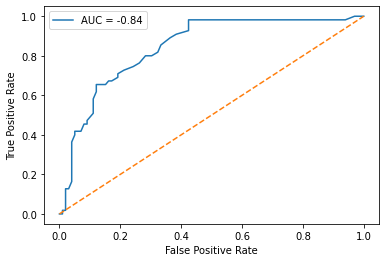

In [20]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve shows the trade off between true positive rate and false positive rate, and the AUC value indicates how well the logistic regression model distinguishes between patients with and without disease.

Comparing with sklearn Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression()
model.fit(X_train, y_train)

sk_probs = model.predict_proba(X_test)[:, 1]
sk_auc = roc_auc_score(y_test, sk_probs)

print("Sklearn AUC:", sk_auc)

Sklearn AUC: 0.8479338842975206


Bonus step : L2 Regularization (overfitting control)

In [22]:
def gradient_descent_l2(X, y, weights, bias, lr, epochs, l2):
    n = len(y)

    for _ in range(epochs):
        y_pred = sigmoid(np.dot(X, weights) + bias)

        dw = (1/n) * np.dot(X.T, (y_pred - y)) + (l2/n)*weights
        db = (1/n) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias

Part B- Question 3

Given: Group A(old method) mean = 65, SD=8, Sample size(n) = 100
Group B(new method) mean = 68, SD= 9, Sample size(n)=100

Task 1- Null and Alternate hypothesis- In hypothesis testing we always start by definig two hypothesis
Null hypothesis(H0): The new teaching method does not improve student scores. The mean scores of both groups are the same Mean score of group-A = mean score of group B, H0​:μA​=μB​ , where μA = mean score of group A
μB = mean score of group B

Alternate hypothesis(H1): the new teaching method improves student scores. The mean score of group B > group A. H1:μB>μA, This is a one tailed test because we are checking for improvement only

Task 2: Choise of Test:z-test or T-test -- we chose a Z-test. Sample size is large (n = 100 for both groups)For large samples (n ≥ 30), the sampling distribution is approximately normal. Standard deviations are known. We are comparing two population means. Therefore a Z-test for difference in means is appropriate

Task 3: Decision process at 5% significance level. Significance level α = 0.05. This means we accept a 5% chance of making a wrong decision. Decision rule: If p-value ≤ 0.05--> reject the null hypothesis. If p-value > 0.05 --> fails to reject the null hypothesis. The p-value tells us how likely it is to see this difference by chance.

Task 4: Conclusion, when 
p-value=0.03, signifiacnce level = 0.05. Since 0.03<0.05. We reject the null hypothesis. There is a strong statistical evidence that the new teaching method improves student scores.

Task 5: Why Ml model accuracy can decrease after improvement. Even though the new teaching method improves scores statistically, the machine learning model accuracy may decrease due to several reasons.
1. Data Distribution Change (Data Drift): 
New teaching method changes student behavior.
Input data patterns become different.
Model trained on old data cannot generalize well.
2. Model Trained on Old Patterns:
The ML model learned patterns from old-method data.
New data follows a different structure.
3. Overfitting:
Model fits old data too closely.
Performs poorly on new unseen data.
4. Noise or Class Imbalance:
New data may contain more variability.
Target distribution may change.

How to fix the Ml model: To improve the model performance:
Retrain the model using new data.
Combine old + new datasets.
Perform feature re-engineering.
Apply regularization techniques.
Use cross-validation.
Monitor performance for concept drift.

Summary: Hypothesis testing shows that the new teaching method is statistically effective.
Z-test is used due to large sample size.
p-value=0.03-->Reject null hypothesis.
ML accuracy may drop due to data drift.
Retaining and updating the model fixes the issue